Linear Regression:

**Y = wX + b**

Y --> Dependent Variable<br>
X --> Independent Variable

w --> weight
b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw
b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

<img src="./Data/linear_regression.png">
<img src="./Data/multiple_LR.png">

## How Gradient Descent Works for Linear Regression

A concise, exam-ready explanation and derivation for gradient descent applied to simple linear regression.

---

### Notation & Model
- Training set: $\{(x_i, y_i)\}_{i=1}^m$  
- Prediction:  
  $$
  y_i^{pred} = w x_i + b
  $$
  where $w$ is the weight and $b$ is the intercept (bias).

---

### 1. Cost Function (Mean Squared Error)
We measure error with the Mean Squared Error (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} \bigl(y_i - y_i^{pred}\bigr)^2
= \frac{1}{m} \sum_{i=1}^{m} \bigl(y_i - (w x_i + b)\bigr)^2
$$

The goal: find $w, b$ that minimize $J(w,b)$.

---

### 2. Compute Partial Derivatives (Gradients)

#### Partial derivative w.r.t. weight $w$
Start with
$$
D_w \equiv \frac{\partial J}{\partial w}
= \frac{\partial}{\partial w}\left(\frac{1}{m}\sum_{i=1}^m (y_i - (w x_i + b))^2\right)
$$

Pull constant outside and apply chain rule:
$$
D_w = \frac{1}{m}\sum_{i=1}^m 2\bigl(y_i - (w x_i + b)\bigr)\cdot\frac{\partial}{\partial w}\bigl(y_i - (w x_i + b)\bigr)
$$

Since $\frac{\partial}{\partial w}\bigl(y_i - (w x_i + b)\bigr) = -x_i$:
$$
D_w = \frac{1}{m}\sum_{i=1}^m 2\bigl(y_i - (w x_i + b)\bigr)(-x_i)
= -\frac{2}{m}\sum_{i=1}^m x_i\bigl(y_i - (w x_i + b)\bigr)
$$

Boxed form:
$$
\boxed{D_w = -\frac{2}{m}\sum_{i=1}^m x_i\,(y_i - y_i^{pred})}
$$

---

#### Partial derivative w.r.t. intercept $b$
Start with
$$
D_b \equiv \frac{\partial J}{\partial b}
= \frac{\partial}{\partial b}\left(\frac{1}{m}\sum_{i=1}^m (y_i - (w x_i + b))^2\right)
$$

Apply chain rule (and $\frac{\partial}{\partial b}(y_i - (w x_i + b)) = -1$):
$$
D_b = \frac{1}{m}\sum_{i=1}^m 2\bigl(y_i - (w x_i + b)\bigr)(-1)
= -\frac{2}{m}\sum_{i=1}^m \bigl(y_i - (w x_i + b)\bigr)
$$

Boxed form:
$$
\boxed{D_b = -\frac{2}{m}\sum_{i=1}^m (y_i - y_i^{pred})}
$$

---

### 3. Gradient Descent Update Rules
Using learning rate $\alpha$:

$$
w \leftarrow w - \alpha\,D_w
\qquad\text{and}\qquad
b \leftarrow b - \alpha\,D_b
$$

Substituting $D_w, D_b$ if you prefer the explicit update:

$$
w \leftarrow w + \alpha\left(\frac{2}{m}\sum_{i=1}^m x_i(y_i - y_i^{pred})\right)
$$

$$
b \leftarrow b + \alpha\left(\frac{2}{m}\sum_{i=1}^m (y_i - y_i^{pred})\right)
$$

(The negative in $D_w,D_b$ becomes a plus in the updates because we subtract the gradient.)

---

### 4. Algorithm (Batch Gradient Descent)
1. Initialize $w, b$ (e.g., small random values or zeros).  
2. Repeat until convergence:
   - Compute predictions $y_i^{pred} = w x_i + b$ for all $i$.
   - Compute gradients $D_w, D_b$ using formulas above.
   - Update parameters using the update rules.
3. Stop when change in $J(w,b)$ or parameters is below a small threshold, or after a max number of iterations.

---

### Practical notes, failure modes & fixes
- **Notation consistency:** Pick one notation and use it throughout ($w,b$ here). Mixing $b$ and $c$ or $w$ and other symbols is confusing and cost you marks in exams.
- **Learning rate $\alpha$**:
  - Too large ⇒ divergence / exploding loss.
  - Too small ⇒ extremely slow convergence.
  - Use learning-rate schedules or try values in $\{10^{-3},10^{-2},10^{-1}\}$ scaled by feature magnitude.
- **Feature scaling (standardization)**: strongly recommended if $x$ values have different ranges — speeds convergence and stabilizes choice of $\alpha$.
- **Batch vs. mini-batch vs. stochastic**:
  - Batch (above): uses full dataset each update — stable gradients but costly on large $m$.
  - Mini-batch: common practical compromise.
  - Stochastic: noisy updates, can escape shallow local issues.
- **Stopping criteria**: small change in $J$, small gradient norm, or patience-based early stopping on validation set.
- **Vectorized form**: use matrix operations for efficiency in code/real projects.
- **Common exam trap**: show chain-rule step — don’t skip it. Exams expect the derivative step explicitly.

---

### Final boxed summary
- Linear Model:
  $$
  Y = wX + b
  $$

- Cost:
  $$
  J(w,b)=\frac{1}{m}\sum_{i=1}^m \bigl(y_i - (w x_i + b)\bigr)^2
  $$

- Gradients:
  $$
  D_w = -\frac{2}{m}\sum_{i=1}^m x_i\bigl(y_i - y_i^{pred}\bigr),\qquad
  D_b = -\frac{2}{m}\sum_{i=1}^m \bigl(y_i - y_i^{pred}\bigr)
  $$

- Update:
  $$
  w \leftarrow w - \alpha D_w,\qquad
  b \leftarrow b - \alpha D_b
  $$


## Dry run with example

We will use **only 3 points** from your table so the math is readable  
(the algorithm is identical for all 9).

| x (Years) | y (Salary) |
| --------- | ---------- |
| 1.1       | 39343      |
| 1.3       | 46205      |
| 1.5       | 37731      |

So:

$$
X =
\begin{bmatrix}
1.1\\
1.3\\
1.5
\end{bmatrix},
\quad
Y =
\begin{bmatrix}
39343\\
46205\\
37731
\end{bmatrix}
$$

* \(m = 3\) data points  
* \(n = 1\) feature  
* learning rate \(\alpha = 0.01\)

---

#### INITIAL VALUES (before iteration 1)

$$
w_0 = 0,\quad b_0 = 0
$$

---

### 🔁 ITERATION 1

#### Step 1: Prediction

Formula:
$$
\hat Y = Xw + b
$$

Substitute:
$$
\hat Y^{(0)} =
\begin{bmatrix}
1.1\\
1.3\\
1.5
\end{bmatrix}\cdot 0 + 0
=
\begin{bmatrix}
0\\
0\\
0
\end{bmatrix}
$$

---

#### Step 2: Error

$$
\text{error} = Y - \hat Y
$$

$$
\begin{bmatrix}
39343\\
46205\\
37731
\end{bmatrix}
-
\begin{bmatrix}
0\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
39343\\
46205\\
37731
\end{bmatrix}
$$

---

#### Step 3: Gradient (D_w)

Your formula:
$$
D_w = -\frac{2}{m}\sum x_i (y_i - \hat y_i)
$$

Compute the summation **explicitly**:

$$
\sum x_i (y_i - \hat y_i)
= 1.1(39343) + 1.3(46205) + 1.5(37731)
$$

$$
= 43277.3 + 60066.5 + 56596.5
= 159940.3
$$

Now:
$$
D_w = -\frac{2}{3} \cdot 159940.3 = -106626.87
$$

---

#### Step 4: Gradient (D_b)

$$
D_b = -\frac{2}{m}\sum (y_i - \hat y_i)
$$

$$
\sum (y_i - \hat y_i)
= 39343 + 46205 + 37731
= 123279
$$

$$
D_b = -\frac{2}{3} \cdot 123279 = -82186
$$

---

#### Step 5: Update parameters

$$
w_1 = w_0 - \alpha D_w
= 0 - 0.01(-106626.87)
= 1066.27
$$

$$
b_1 = b_0 - \alpha D_b
= 0 - 0.01(-82186)
= 821.86
$$

✅ **After Iteration 1**

$$
w_1 = 1066.27,\quad b_1 = 821.86
$$

---

### 🔁 ITERATION 2

#### Step 1: New Prediction

$$
\hat Y^{(1)} = Xw_1 + b_1
$$

Compute **row by row**:

For \(x=1.1\):
$$
\hat y = 1.1(1066.27) + 821.86 = 1995.76
$$

For \(x=1.3\):
$$
\hat y = 1.3(1066.27) + 821.86 = 2208.01
$$

For \(x=1.5\):
$$
\hat y = 1.5(1066.27) + 821.86 = 2420.27
$$

$$
\hat Y^{(1)} =
\begin{bmatrix}
1995.76\\
2208.01\\
2420.27
\end{bmatrix}
$$

---

#### Step 2: Error

$$
\text{error} = Y - \hat Y^{(1)}
$$

$$
\begin{bmatrix}
37347.24\\
43996.99\\
35310.73
\end{bmatrix}
$$

---

#### Step 3: Gradient (D_w)

$$
\sum x_i (y_i - \hat y_i)
= 1.1(37347.24) + 1.3(43996.99) + 1.5(35310.73)
$$

$$
= 41082.0 + 57196.1 + 52966.1
= 151244.2
$$

$$
D_w = -\frac{2}{3} \cdot 151244.2 = -100829.47
$$

---

#### Step 4: Gradient (D_b)

$$
\sum (y_i - \hat y_i)
= 37347.24 + 43996.99 + 35310.73
= 117654.96
$$

$$
D_b = -\frac{2}{3} \cdot 117654.96 = -78436.64
$$

---

#### Step 5: Update again

$$
w_2 = 1066.27 - 0.01(-100829.47) = 2074.56
$$

$$
b_2 = 821.86 - 0.01(-78436.64) = 1606.23
$$

✅ **After Iteration 2**

$$
w_2 = 2074.56,\quad b_2 = 1606.23
$$

---


### dependencies

In [2]:
# importing numpy library
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import linear_regression as LR

### Data preprocessing

In [3]:
# from csv file to pandas dataframe
salary_data = pd.read_csv("./Data/salary_data.csv")
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [5]:
# print number of rows and columns in dataset
salary_data.shape           

(30, 2)

In [6]:
# cheaking for missing values
salary_data.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

### splitting feature and target

In [7]:
X = salary_data.iloc[:,:-1].values # Take all rows, all columns except the last, and convert to NumPy array
Y = salary_data.iloc[:,1].values # all row and col 1

In [8]:
print(X)
print(Y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


### Train Test split

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X,
                                                    Y, 
                                                    test_size=0.33, 
                                                    random_state=2)

### Training the ML model

In [10]:
model = LR.Linear_Regression(learning_rate=0.01, no_of_iterations=500)

In [11]:
model.fit(X_train,Y_train)

In [12]:
# printing the parameter values
print('weight = ',model.w[0])
print('bias = ',model.b)

# salary = 9580(years_of_experience) + 23226

weight =  9967.727542194507
bias =  20457.28682781222


### Prediction

In [13]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[ 33415.33263267  31421.78712423  65312.06076769  57337.87873393
  91228.15237739  80263.65208098 102192.65267381  50360.4694544
  40392.7419122   88237.83411473]


### Visualization

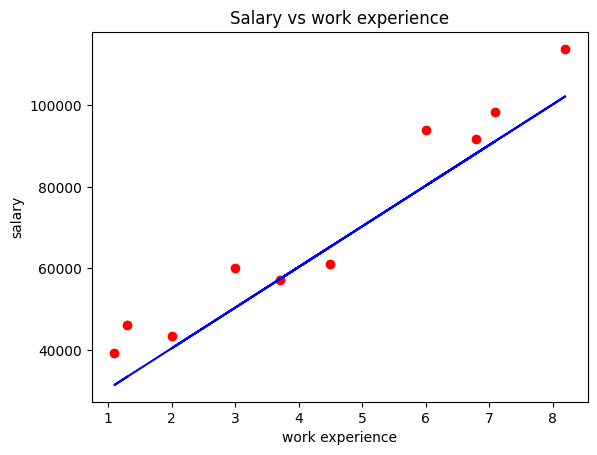

In [14]:
plt.scatter(X_test, Y_test, color='red')
plt.plot(X_test,test_data_prediction, color='blue')
plt.xlabel('work experience')
plt.ylabel('salary')
plt.title('Salary vs work experience')
plt.show()